In [3]:
!pip install facenet-pytorch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 107.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 90.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 69.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Using Device: cuda
✅ Model Loaded Successfully


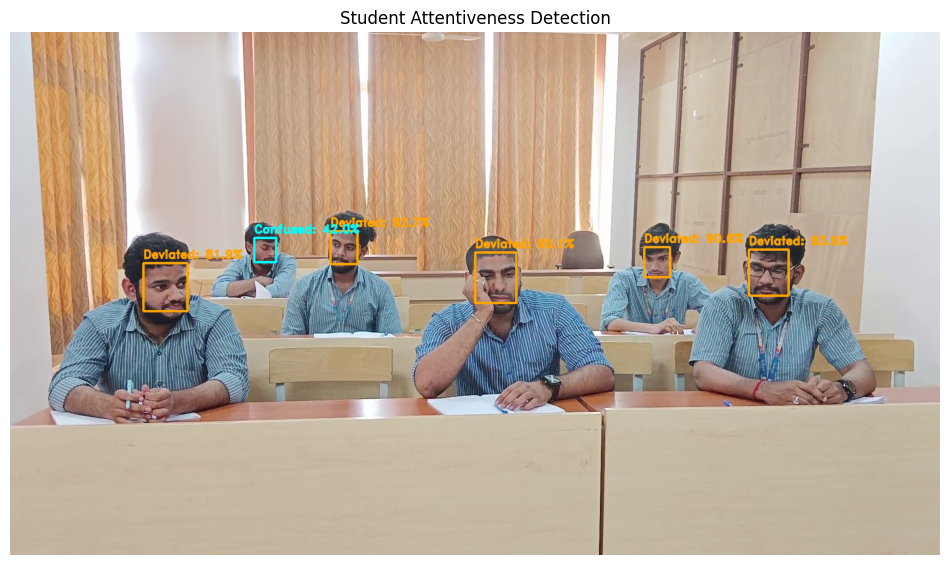


Detection Summary
{'Bored': 0, 'Confused': 1, 'Deviated': 5, 'Focused': 0, 'Sleepy': 0}
Overall Engagement Index (OEI): 53.33%
Random Engagement Index (REI): 56.67%


In [ ]:
!pip install facenet-pytorch -q

import os
import cv2
import time
import torch
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms, models
from facenet_pytorch import MTCNN



device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)
MODEL_PATH = "/kaggle/working/densenet_weights.pkl"



IMAGE_PATH = "/kaggle/input/datasets/satyaganjam/testing-images/frame_57.jpg"

CLASS_NAMES = [
    'Bored',
    'Confused',
    'Deviated',
    'Focused',
    'Sleepy'
]

CLASS_COLORS = {
    'Confused': (0, 255, 255),
    'Deviated': (255, 165, 0),
    'Bored': (0, 0, 255),
    'Sleepy': (255, 255, 0),
    'Focused': (0, 255, 0)
}



ENGAGEMENT_WEIGHTS = {
    'Focused': 1.0,
    'Confused': 0.7,
    'Deviated': 0.5,
    'Sleepy': 0.3,
    'Bored': 0.2
}



class DenseNetFixed(torch.nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.backbone = models.densenet121(weights=None)

        in_f = self.backbone.classifier.in_features

        self.backbone.classifier = torch.nn.Sequential(

            torch.nn.Linear(in_f, 512),

            torch.nn.ReLU(),

            torch.nn.Dropout(0.4),

            torch.nn.Linear(512, num_classes)
        )

    def forward(self, x):

        return self.backbone(x)



model = DenseNetFixed(
    len(CLASS_NAMES)
).to(device)

with open(MODEL_PATH, 'rb') as f:

    model.load_state_dict(
        pickle.load(f)
    )

model.eval()

print("✅ Model Loaded Successfully")



mtcnn = MTCNN(
    keep_all=True,
    device=device
)



test_tf = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])



img = cv2.imread(IMAGE_PATH)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

draw_img = img_rgb.copy()



boxes, _ = mtcnn.detect(img_rgb)

counts = {
    name: 0 for name in CLASS_NAMES
}

detected_labels = []


if boxes is not None:

    for box in boxes:

        ox1, oy1, ox2, oy2 = map(int, box)

        w = ox2 - ox1
        h = oy2 - oy1

        x1 = int(ox1 + (w * 0.05))
        x2 = int(ox2 - (w * 0.05))

        y1 = int(oy1)
        y2 = int(oy2 - (h * 0.15))

        face = img_rgb[
            max(0, y1):y2,
            max(0, x1):x2
        ]

        if face.size == 0:
            continue

        
        face_tensor = test_tf(face)\
            .unsqueeze(0)\
            .to(device)

        
        with torch.no_grad():

            output = model(face_tensor)

            probs = torch.softmax(
                output,
                dim=1
            )[0]

            conf, idx = torch.max(
                probs,
                dim=0
            )

        label = CLASS_NAMES[idx]

        detected_labels.append(label)

        confidence = conf.item() * 100

        counts[label] += 1

        color = CLASS_COLORS[label]

        
        cv2.rectangle(
            draw_img,
            (x1, y1),
            (x2, y2),
            color,
            3
        )

        
        text = f"{label}: {confidence:.1f}%"

        cv2.putText(
            draw_img,
            text,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_DUPLEX,
            0.8,
            color,
            2,
            cv2.LINE_AA
        )

else:

    print("⚠ No faces detected")



total_students = sum(counts.values())

weighted_sum = 0

for label, count in counts.items():

    weighted_sum += (
        count * ENGAGEMENT_WEIGHTS[label]
    )

if total_students > 0:

    OEI = (
        weighted_sum / total_students
    ) * 100

else:

    OEI = 0



if len(detected_labels) > 0:

    random_students = random.sample(
        detected_labels,
        min(3, len(detected_labels))
    )

    rei_sum = 0

    for lbl in random_students:

        rei_sum += ENGAGEMENT_WEIGHTS[lbl]

    REI = (
        rei_sum / len(random_students)
    ) * 100

else:

    REI = 0



plt.figure(figsize=(12,8))

plt.imshow(draw_img)

plt.axis("off")

plt.title("Student Attentiveness Detection")

plt.show()



print("\n================================")

print("Detection Summary")

print(counts)

print("================================")

print(f"Overall Engagement Index (OEI): {OEI:.2f}%")

print(f"Random Engagement Index (REI): {REI:.2f}%")

print("================================")

Using Device: cuda
✅ Model Loaded Successfully


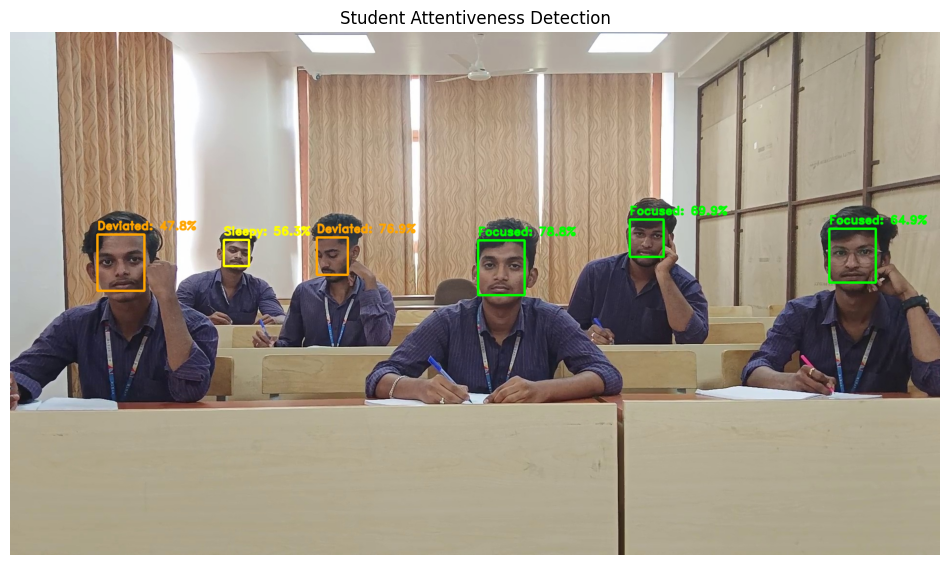


Detection Summary
{'Bored': 0, 'Confused': 0, 'Deviated': 2, 'Focused': 3, 'Sleepy': 1}
Overall Engagement Index (OEI): 71.67%
Random Engagement Index (REI): 60.00%


In [ ]:


!pip install facenet-pytorch -q



import os
import cv2
import time
import torch
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms, models
from facenet_pytorch import MTCNN



device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)



MODEL_PATH = "/kaggle/working/densenet_weights.pkl"



IMAGE_PATH = "/kaggle/input/datasets/satyaganjam/testing-images/frame_8.jpg"



CLASS_NAMES = [
    'Bored',
    'Confused',
    'Deviated',
    'Focused',
    'Sleepy'
]



CLASS_COLORS = {
    'Confused': (0, 255, 255),
    'Deviated': (255, 165, 0),
    'Bored': (0, 0, 255),
    'Sleepy': (255, 255, 0),
    'Focused': (0, 255, 0)
}



ENGAGEMENT_WEIGHTS = {
    'Focused': 1.0,
    'Confused': 0.7,
    'Deviated': 0.5,
    'Sleepy': 0.3,
    'Bored': 0.2
}



class DenseNetFixed(torch.nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.backbone = models.densenet121(weights=None)

        in_f = self.backbone.classifier.in_features

        self.backbone.classifier = torch.nn.Sequential(

            torch.nn.Linear(in_f, 512),

            torch.nn.ReLU(),

            torch.nn.Dropout(0.4),

            torch.nn.Linear(512, num_classes)
        )

    def forward(self, x):

        return self.backbone(x)



model = DenseNetFixed(
    len(CLASS_NAMES)
).to(device)

with open(MODEL_PATH, 'rb') as f:

    model.load_state_dict(
        pickle.load(f)
    )

model.eval()

print("✅ Model Loaded Successfully")



mtcnn = MTCNN(
    keep_all=True,
    device=device
)


test_tf = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])



img = cv2.imread(IMAGE_PATH)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

draw_img = img_rgb.copy()



boxes, _ = mtcnn.detect(img_rgb)

counts = {
    name: 0 for name in CLASS_NAMES
}

detected_labels = []



if boxes is not None:

    for box in boxes:

        ox1, oy1, ox2, oy2 = map(int, box)

        w = ox2 - ox1
        h = oy2 - oy1

        x1 = int(ox1 + (w * 0.05))
        x2 = int(ox2 - (w * 0.05))

        y1 = int(oy1)
        y2 = int(oy2 - (h * 0.15))

        face = img_rgb[
            max(0, y1):y2,
            max(0, x1):x2
        ]

        if face.size == 0:
            continue

        
        face_tensor = test_tf(face)\
            .unsqueeze(0)\
            .to(device)

        
        with torch.no_grad():

            output = model(face_tensor)

            probs = torch.softmax(
                output,
                dim=1
            )[0]

            conf, idx = torch.max(
                probs,
                dim=0
            )

        label = CLASS_NAMES[idx]

        detected_labels.append(label)

        confidence = conf.item() * 100

        counts[label] += 1

        color = CLASS_COLORS[label]

        
        cv2.rectangle(
            draw_img,
            (x1, y1),
            (x2, y2),
            color,
            3
        )

        
        text = f"{label}: {confidence:.1f}%"

        cv2.putText(
            draw_img,
            text,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_DUPLEX,
            0.8,
            color,
            2,
            cv2.LINE_AA
        )

else:

    print("⚠ No faces detected")



total_students = sum(counts.values())

weighted_sum = 0

for label, count in counts.items():

    weighted_sum += (
        count * ENGAGEMENT_WEIGHTS[label]
    )

if total_students > 0:

    OEI = (
        weighted_sum / total_students
    ) * 100

else:

    OEI = 0



if len(detected_labels) > 0:

    random_students = random.sample(
        detected_labels,
        min(3, len(detected_labels))
    )

    rei_sum = 0

    for lbl in random_students:

        rei_sum += ENGAGEMENT_WEIGHTS[lbl]

    REI = (
        rei_sum / len(random_students)
    ) * 100

else:

    REI = 0



plt.figure(figsize=(12,8))

plt.imshow(draw_img)

plt.axis("off")

plt.title("Student Attentiveness Detection")

plt.show()



print("\n================================")

print("Detection Summary")

print(counts)

print("================================")

print(f"Overall Engagement Index (OEI): {OEI:.2f}%")

print(f"Random Engagement Index (REI): {REI:.2f}%")

print("================================")

Using Device: cuda
✅ Model Loaded Successfully


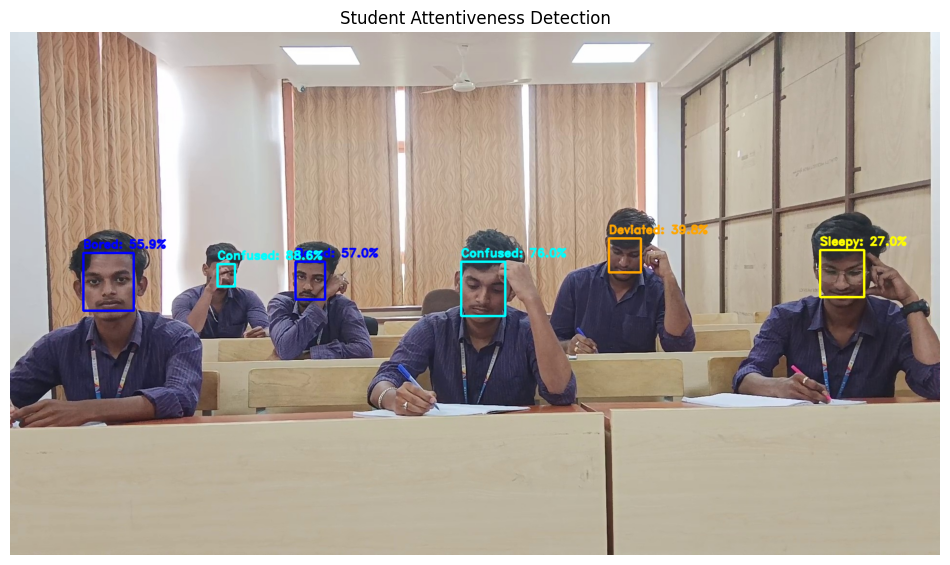


Detection Summary
{'Bored': 2, 'Confused': 2, 'Deviated': 1, 'Focused': 0, 'Sleepy': 1}
Overall Engagement Index (OEI): 43.33%
Random Engagement Index (REI): 23.33%


In [ ]:


!pip install facenet-pytorch -q



import os
import cv2
import time
import torch
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms, models
from facenet_pytorch import MTCNN



device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)



MODEL_PATH = "/kaggle/working/densenet_weights.pkl"



IMAGE_PATH = "/kaggle/input/datasets/satyaganjam/testing-images/frame_48.jpg"



CLASS_NAMES = [
    'Bored',
    'Confused',
    'Deviated',
    'Focused',
    'Sleepy'
]



CLASS_COLORS = {
    'Confused': (0, 255, 255),
    'Deviated': (255, 165, 0),
    'Bored': (0, 0, 255),
    'Sleepy': (255, 255, 0),
    'Focused': (0, 255, 0)
}



ENGAGEMENT_WEIGHTS = {
    'Focused': 1.0,
    'Confused': 0.7,
    'Deviated': 0.5,
    'Sleepy': 0.3,
    'Bored': 0.2
}



class DenseNetFixed(torch.nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.backbone = models.densenet121(weights=None)

        in_f = self.backbone.classifier.in_features

        self.backbone.classifier = torch.nn.Sequential(

            torch.nn.Linear(in_f, 512),

            torch.nn.ReLU(),

            torch.nn.Dropout(0.4),

            torch.nn.Linear(512, num_classes)
        )

    def forward(self, x):

        return self.backbone(x)



model = DenseNetFixed(
    len(CLASS_NAMES)
).to(device)

with open(MODEL_PATH, 'rb') as f:

    model.load_state_dict(
        pickle.load(f)
    )

model.eval()

print("✅ Model Loaded Successfully")



mtcnn = MTCNN(
    keep_all=True,
    device=device
)



test_tf = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])



img = cv2.imread(IMAGE_PATH)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

draw_img = img_rgb.copy()



boxes, _ = mtcnn.detect(img_rgb)

counts = {
    name: 0 for name in CLASS_NAMES
}

detected_labels = []



if boxes is not None:

    for box in boxes:

        ox1, oy1, ox2, oy2 = map(int, box)

        w = ox2 - ox1
        h = oy2 - oy1

        x1 = int(ox1 + (w * 0.05))
        x2 = int(ox2 - (w * 0.05))

        y1 = int(oy1)
        y2 = int(oy2 - (h * 0.15))

        face = img_rgb[
            max(0, y1):y2,
            max(0, x1):x2
        ]

        if face.size == 0:
            continue

        
        face_tensor = test_tf(face)\
            .unsqueeze(0)\
            .to(device)

        
        with torch.no_grad():

            output = model(face_tensor)

            probs = torch.softmax(
                output,
                dim=1
            )[0]

            conf, idx = torch.max(
                probs,
                dim=0
            )

        label = CLASS_NAMES[idx]

        detected_labels.append(label)

        confidence = conf.item() * 100

        counts[label] += 1

        color = CLASS_COLORS[label]

        
        cv2.rectangle(
            draw_img,
            (x1, y1),
            (x2, y2),
            color,
            3
        )

        
        text = f"{label}: {confidence:.1f}%"

        cv2.putText(
            draw_img,
            text,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_DUPLEX,
            0.8,
            color,
            2,
            cv2.LINE_AA
        )

else:

    print("⚠ No faces detected")



total_students = sum(counts.values())

weighted_sum = 0

for label, count in counts.items():

    weighted_sum += (
        count * ENGAGEMENT_WEIGHTS[label]
    )

if total_students > 0:

    OEI = (
        weighted_sum / total_students
    ) * 100

else:

    OEI = 0



if len(detected_labels) > 0:

    random_students = random.sample(
        detected_labels,
        min(3, len(detected_labels))
    )

    rei_sum = 0

    for lbl in random_students:

        rei_sum += ENGAGEMENT_WEIGHTS[lbl]

    REI = (
        rei_sum / len(random_students)
    ) * 100

else:

    REI = 0



plt.figure(figsize=(12,8))

plt.imshow(draw_img)

plt.axis("off")

plt.title("Student Attentiveness Detection")

plt.show()



print("\n================================")

print("Detection Summary")

print(counts)

print("================================")

print(f"Overall Engagement Index (OEI): {OEI:.2f}%")

print(f"Random Engagement Index (REI): {REI:.2f}%")

print("================================")